# SHAP analysis — DeepSHAP + post-hoc aggregation (|SHAP| per feature)

This notebook reads **per-feature DeepSHAP** artefacts only (`artifacts/shap/…`). Group-level numbers are built **after** attribution:

- Each row of `shap_mean.parquet` is one feature $f$ at one date $t$ and maturity $m$, with `abs_mean_shap` $= \bigl|\overline{\text{SHAP}}^{\,\text{seed}}_{f,m,t}\bigr|$ (absolute value of the top-$k$ seed **mean** SHAP).
- For an economic block $G$ (forward curve or a FRED-MD theme), we define **gross block activity**
  \[
  \mathcal{A}_{G,m}(t) \;= \;\sum_{f \in G} \bigl|\overline{\text{SHAP}}_{f,m,t}\bigr|.
  \]
- **Shares** and time series normalize $\mathcal{A}_{G,m}(t)$ across blocks so they sum to 100% at each $(m,t)$ in the parquet; **here** we fix one $m=$ **`MATURITY_FOR_COMPARE`** and compare models, so figures read as shares at each $(\mathrm{model}, t)$. Composition time-averages $\mathcal{A}$ then row-normalises across blocks.

**Note:** The data-prep code cell mirrors **`shap_compute`** for reproducibility; **plots depend only on parquet `feature` strings** and derived **`block_mass`** (see the next markdown cell). Set **`MACRO_PANEL`** to match how the SHAP artefacts were produced.

**Model comparison.** The loader pulls **both** `macro_forward` and `group_ensemble` runs and fixes **one maturity** via `MATURITY_FOR_COMPARE` (default 10Y = `'120'`). **No group-Shapley** — recompute is not required if `notebooks/shap/shap_compute.ipynb` has already written `shap_mean.parquet` / `per_seed_shap.parquet`.

**Contents.** (1) Composition across models — (2) Bianchi-style ranking + group pie — (3) **Merged themes · importance** (Real Activity + coarse splits, compare models) — (4) macro vs forwards over time (one panel per model) — **(4b) NBER-resesjoner:** makro-andel i resesjon vs. øvrige måneder — (5) per-block shares over time — (6) seed stability from `per_seed_shap`.


**Data prep (next cell).** Optional sanity check + same template recipe as `shap_compute.ipynb`. **All figures** aggregate the loaded `shap_mean.parquet`: each `feature` string is split by **`parse_block`** / **`parse_display`** (`fred::Group::Series`). **`BLOCK_ORDER`** is built from **`block_mass`** (observed SHAP mass per block), **not** from `X.columns` — later cells do **not** use `X` or `s2g`. So a “wide” static `fred_md` panel does **not** affect plot correctness; only rows that **actually appear** in the parquet matter.

**Revised vs realtime — same feature *names*:** Both use `get_fred_data` + **`prepare_macro_panel_for_project`** (same column list: FRED-MD minus the two dropped series). **`MACRO_PANEL`** only switches **`shift(1)`** on that static panel for the template; realtime **training/SHAP** then **replaces** the `fred` block with **`ForecastVintageMacroStore`**. The vintage panel is built from the same registry/mnemonics — you do **not** get a strictly larger “revised CSV column set” vs “realtime column set” in the design matrix definition. The **model** may use a **subset** of columns (after `drop_unavailable_columns` during training); SHAP only emits those features — analysis never expects the full 124 in every run.

**Gap and holding period:** For **reading** existing SHAP outputs you do **not** hand-set gap: `shap_compute` already used your run’s **`run_config.json`** (`gap`, refit indices, etc.) when building backgrounds and eval rows. **`MATURITY_FOR_COMPARE`** picks which **output head** (horizon label in months) you plot — align that with the **return holding period** you care about (e.g. `120` = 12‑month excess-return **target** for that head). Wrong maturity mislabels the **economic** interpretation, not the internal SHAP algebra.

- Match **`shap_compute`**: **KR**, **`2025-06-30`**, **monthly forwards** (`get_monthly_forward_rates` on full monthly yield grid — same as **`orchestrator_ann_runs`** with `MONTHLY=True`), **`MACRO_PANEL`**: **`"realtime"`** = no `shift(1)` on template; **`"revised"`** = `shift(1)` for legacy revised SHAP runs.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Repo root: cwd may be repo root, notebooks/, or notebooks/shap/
REPO_ROOT = Path.cwd()
for _ in range(5):
    if (REPO_ROOT / "utils" / "base_utils.py").exists():
        break
    REPO_ROOT = REPO_ROOT.parent
else:
    raise RuntimeError("Could not find repo root (utils/base_utils.py).")
sys.path.insert(0, str(REPO_ROOT))

import utils.base_utils as bu
from utils.macro_grouping import add_group_level, build_full_group_mapping

# Align with shap_compute.ipynb / realtime orchestrator (kr_1971_08_2025_06)
start_date = "1971-08-31"
end_date = "2025-06-30"
MACRO_PANEL = "realtime"  # "revised" -> shift(1) for static FRED-MD (legacy revised-macro SHAP only)

yields = bu.get_yields(
    type="kr",
    start=start_date,
    end=end_date,
    maturities=[str(i) for i in range(12, 121) if i % 12 == 0],
)
monthly_yields = bu.get_yields(
    type="kr",
    start=start_date,
    end=end_date,
    maturities=[str(i) for i in range(1, 121)],
)
forward = bu.get_monthly_forward_rates(monthly_yields)
xr = bu.get_excess_returns(yields, horizon=12).dropna()

fred_md_start_date = pd.to_datetime(start_date) - pd.DateOffset(months=6)
fred_md_raw = bu.get_fred_data(
    str(REPO_ROOT / "data" / "2026-01-MD.csv"),
    start=fred_md_start_date,
    end=end_date,
)

fred_md = fred_md_raw.copy() if MACRO_PANEL == "realtime" else fred_md_raw.shift(1)
fred_md = fred_md[start_date:end_date]
fred_md = bu.prepare_macro_panel_for_project(fred_md)

yields = yields.loc[yields.index <= xr.index[-1]]
monthly_yields = monthly_yields.loc[monthly_yields.index <= xr.index[-1]]
forward = forward.loc[forward.index <= xr.index[-1]]
xr = xr.loc[xr.index <= xr.index[-1]]
fred_md = fred_md.loc[fred_md.index <= xr.index[-1]]

s2g = build_full_group_mapping(fred_md, forward, yields)
X = pd.concat([fred_md, forward, yields], axis=1, keys=["fred", "forward", "yields"])
X = add_group_level(X, s2g, level_name="group")
X = X.sort_index(axis=1, level="group")
X = X.ffill()

dates = xr.index
print(
    f"MACRO_PANEL={MACRO_PANEL!r} | X shape: {X.shape} | dates:",
    dates[0].date(),
    "->",
    dates[-1].date(),
)

MACRO_PANEL='realtime' | X shape: (635, 144) | dates: 1971-08-31 -> 2024-06-30


/home/ulrikts/Documents/NTNU/TIO4900-Replication/utils/macro_grouping.py:219: UserWarning: The following series are defined in get_fredmd_grouping() but are not present in the FRED-MD data: ['ACOGNO', 'TWEXAFEGSMTHx']. They may have been dropped or renamed.
  warnings.warn(
/home/ulrikts/Documents/NTNU/TIO4900-Replication/utils/macro_grouping.py:168: UserWarning: 2 entries in series_to_group are not present in the DataFrame columns: ['ACOGNO', 'TWEXAFEGSMTHx']
  warnings.warn(


## Realtime macro variable count (expanding window)

Uses **`ForecastVintageMacroStore`** and the same rules as **`expanding_window(realtime=True)`** / SHAP compute:

- At each OOS forecast date \(t\), build the vintage-correct macro panel as-of \(t\).
- Training window ends at \(t - \texttt{gap}\) (gap = 11 for annual non-overlapping runs).
- A macro series **contributes** if it is non-missing on **every** month in `START … train_end` after replacing the `fred` block (`drop_unavailable_columns` logic).

**Plot:** number of macro series in the training set over forecast dates. Red markers = dates where at least one **new** series enters (relative to the previous forecast date).

**Note:** The first OOS date is the **baseline** (initial available set); only **subsequent** entries are listed in the table. Series can also **drop out** when a revised vintage adds earlier missing values (rare); those are listed separately.

**Runtime:** ~2 minutes for 414 OOS months (one vintage panel per month). Run after the data-prep cell (`X`, `dates` must exist).



/home/ulrikts/Documents/NTNU/TIO4900-Replication/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
vintage macro panels: 100%|██████████| 414/414 [01:53<00:00,  3.66it/s]


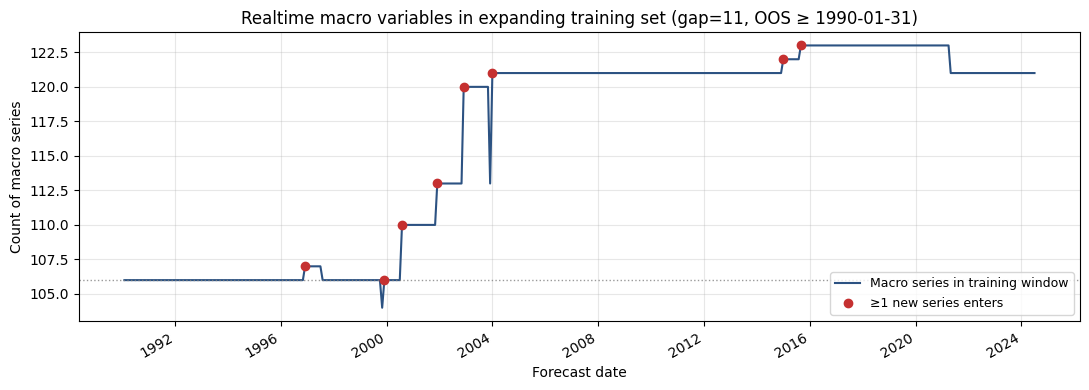

Baseline at first OOS forecast (1990-01-31): 106 macro series
Range over OOS: 104 – 123

=== New macro variables entering the training set (28 events) ===


,date,variable
0,1996-11-30,INVEST
1,1999-11-30,RPI
2,1999-11-30,W875RX1
3,2000-07-31,DDURRG3M086SBEA
4,2000-07-31,DNDGRG3M086SBEA
5,2000-07-31,DSERRG3M086SBEA
6,2000-07-31,PCEPI
7,2001-11-30,BUSLOANS
8,2001-11-30,INVEST
9,2001-11-30,REALLN



=== Macro variables leaving the training set (13 events) ===


,date,variable
0,1997-07-31,INVEST
1,1999-10-31,RPI
2,1999-10-31,W875RX1
3,2003-11-30,CONSPI
4,2003-11-30,DDURRG3M086SBEA
5,2003-11-30,DNDGRG3M086SBEA
6,2003-11-30,DSERRG3M086SBEA
7,2003-11-30,PCEPI
8,2003-11-30,RPI
9,2003-11-30,W875RX1


In [2]:
from tqdm.auto import tqdm

from utils.forecast_vintages import ForecastVintageMacroStore
from utils.window_utils import _realtime_feature_frame, _select_train_available_columns

OOS_START = pd.Timestamp("1990-01-31")
GAP = 11  # matches orchestrator / SHAP runs (annual non-overlapping)

if MACRO_PANEL != "realtime":
    print("Macro vintage scan applies only to MACRO_PANEL='realtime' (current: %r)." % MACRO_PANEL)
else:
    store = ForecastVintageMacroStore()
    panel_cache: dict[pd.Timestamp, object] = {}
    oos_idx = np.where(dates >= OOS_START)[0]

    count_rows = []
    entry_rows = []
    exit_rows = []
    prev_macro: set[str] | None = None
    baseline_date = baseline_n = None

    for t in tqdm(oos_idx, desc="vintage macro panels"):
        fc_date = pd.Timestamp(dates[t])
        panel = panel_cache.get(fc_date)
        if panel is None:
            panel = store.panel_for_forecast_date(fc_date, start=dates[0], end=fc_date)
            panel_cache[fc_date] = panel

        X_rt = _realtime_feature_frame(X, panel.transformed, t)
        train_end = t - GAP
        if train_end < 1:
            continue

        avail_cols = _select_train_available_columns(X_rt.iloc[:train_end])
        macro_names = sorted(
            col[-1]
            for col in avail_cols
            if isinstance(col, tuple) and col[0] == "fred"
        )
        macro_set = set(macro_names)

        n_new = n_exit = 0
        if prev_macro is None:
            baseline_date = fc_date
            baseline_n = len(macro_names)
        else:
            for v in sorted(macro_set - prev_macro):
                entry_rows.append({"date": fc_date, "variable": v})
                n_new += 1
            for v in sorted(prev_macro - macro_set):
                exit_rows.append({"date": fc_date, "variable": v})
                n_exit += 1

        count_rows.append(
            {
                "date": fc_date,
                "n_macro_train": len(macro_names),
                "n_new": n_new,
                "n_exit": n_exit,
            }
        )
        prev_macro = macro_set

    macro_count_ts = pd.DataFrame(count_rows).set_index("date")
    entry_df = pd.DataFrame(entry_rows)
    exit_df = pd.DataFrame(exit_rows)

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(
        macro_count_ts.index,
        macro_count_ts["n_macro_train"],
        color="#2c5282",
        lw=1.5,
        label="Macro series in training window",
    )
    if not entry_df.empty:
        entry_dates = entry_df.groupby("date").size()
        y_at_entry = macro_count_ts.loc[entry_dates.index, "n_macro_train"]
        ax.scatter(
            entry_dates.index,
            y_at_entry,
            color="#c53030",
            s=36,
            zorder=5,
            label="≥1 new series enters",
        )
    if baseline_n is not None:
        ax.axhline(baseline_n, color="gray", ls=":", lw=1, alpha=0.8)
    ax.set_ylabel("Count of macro series")
    ax.set_xlabel("Forecast date")
    ax.set_title(
        f"Realtime macro variables in expanding training set "
        f"(gap={GAP}, OOS ≥ {OOS_START.date()})"
    )
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

    print(f"Baseline at first OOS forecast ({baseline_date.date()}): {baseline_n} macro series")
    print(
        f"Range over OOS: {macro_count_ts['n_macro_train'].min()} –"
        f" {macro_count_ts['n_macro_train'].max()}"
    )

    print(f"\n=== New macro variables entering the training set ({len(entry_df)} events) ===")
    if entry_df.empty:
        print("(none after baseline)")
    else:
        display(entry_df.reset_index(drop=True))

    if not exit_df.empty:
        print(f"\n=== Macro variables leaving the training set ({len(exit_df)} events) ===")
        display(exit_df.reset_index(drop=True))



## Realtime macro usage via `expanding_window(realtime=True)`

Same OOS dates and **`gap=11`**, but macro availability is read from the **actual forecasting engine** — not by calling `ForecastVintageMacroStore` directly.

At each refit, `expanding_window` (defaults: `drop_unavailable_columns=True`, `carry_forward_latest=True`) rebuilds the vintage macro block, drops incomplete columns, forward-fills survivors, then passes **`selected_columns`** to `save_callback`. We record those **`fred`** names as the macro set the model would train on.

Uses a dummy `HistoricalMeanModel` (y is irrelevant); only column selection matters. **Runtime:** ~2–3 min (full OOS loop). Run after the data-prep cell (`X`, `dates`).

In [3]:
import utils.window_utils as wu


class _ExpandingWindowColumnProbe:
    """Dummy forecaster — only column selection in expanding_window matters."""

    def fit(self, X, y):
        return self

    def predict(self, X):
        n = len(X)
        return np.zeros(n)


OOS_START = pd.Timestamp("1990-01-31")
GAP = 11

if MACRO_PANEL != "realtime":
    print("expanding_window macro probe applies only to MACRO_PANEL='realtime' (current: %r)." % MACRO_PANEL)
else:
    y_probe = xr["120"].reindex(dates).values  # target choice irrelevant for column selection

    ew_count_rows: list[dict] = []
    ew_entry_rows: list[dict] = []
    ew_exit_rows: list[dict] = []
    ew_prev_macro: set[str] | None = None
    ew_ever_used: set[str] = set()
    ew_baseline_date = ew_baseline_n = None

    def _fred_names_from_selected(selected_columns) -> set[str]:
        if selected_columns is None:
            return set()
        return {
            col[-1]
            for col in selected_columns
            if isinstance(col, tuple) and col[0] == "fred"
        }

    def _ew_probe_cb(*, selected_columns, date_value, **kwargs):
        nonlocal ew_prev_macro, ew_baseline_date, ew_baseline_n, ew_ever_used
        fc_date = pd.Timestamp(date_value)
        macro_set = _fred_names_from_selected(selected_columns)
        ew_ever_used |= macro_set

        n_new = n_exit = 0
        if ew_prev_macro is None:
            ew_baseline_date = fc_date
            ew_baseline_n = len(macro_set)
        else:
            for v in sorted(macro_set - ew_prev_macro):
                ew_entry_rows.append({"date": fc_date, "variable": v})
                n_new += 1
            for v in sorted(ew_prev_macro - macro_set):
                ew_exit_rows.append({"date": fc_date, "variable": v})
                n_exit += 1

        ew_count_rows.append(
            {
                "date": fc_date,
                "n_macro_train": len(macro_set),
                "n_new": n_new,
                "n_exit": n_exit,
            }
        )
        ew_prev_macro = macro_set

    _ = wu.expanding_window(
        _ExpandingWindowColumnProbe(),
        X,
        y_probe,
        dates,
        OOS_START,
        gap=GAP,
        refit_freq=1,
        save_callback=_ew_probe_cb,
        progress=True,
        tqdm_desc="expanding_window realtime probe",
        realtime=True,
    )

    ew_macro_count_ts = pd.DataFrame(ew_count_rows).set_index("date")
    ew_entry_df = pd.DataFrame(ew_entry_rows)
    ew_exit_df = pd.DataFrame(ew_exit_rows)

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(
        ew_macro_count_ts.index,
        ew_macro_count_ts["n_macro_train"],
        color="#276749",
        lw=1.5,
        label="Macro series selected by expanding_window",
    )
    if not ew_entry_df.empty:
        ew_entry_dates = ew_entry_df.groupby("date").size()
        y_at_entry = ew_macro_count_ts.loc[ew_entry_dates.index, "n_macro_train"]
        ax.scatter(
            ew_entry_dates.index,
            y_at_entry,
            color="#c53030",
            s=36,
            zorder=5,
            label="≥1 new series enters",
        )
    if ew_baseline_n is not None:
        ax.axhline(ew_baseline_n, color="gray", ls=":", lw=1, alpha=0.8)
    ax.set_ylabel("Count of macro series")
    ax.set_xlabel("Forecast date")
    ax.set_title(
        f"Realtime macro via expanding_window (gap={GAP}, OOS ≥ {OOS_START.date()})"
    )
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

    print(
        f"Baseline at first OOS forecast ({ew_baseline_date.date()}): "
        f"{ew_baseline_n} macro series"
    )
    print(
        f"Range over OOS: {ew_macro_count_ts['n_macro_train'].min()} –"
        f" {ew_macro_count_ts['n_macro_train'].max()}"
    )

    all_fred = sorted(
        col[-1] for col in X.columns if isinstance(col, tuple) and col[0] == "fred"
    )
    never_used = sorted(set(all_fred) - ew_ever_used)
    print(f"\nTemplate fred columns: {len(all_fred)}")
    print(f"Ever selected over OOS: {len(ew_ever_used)}")
    if never_used:
        print(f"Never selected ({len(never_used)}): {never_used}")

    print(f"\n=== New macro variables entering ({len(ew_entry_df)} events) ===")
    if ew_entry_df.empty:
        print("(none after baseline)")
    else:
        display(ew_entry_df.reset_index(drop=True))

    if not ew_exit_df.empty:
        print(f"\n=== Macro variables leaving ({len(ew_exit_df)} events) ===")
        display(ew_exit_df.reset_index(drop=True))

    if "macro_count_ts" in globals():
        joined = ew_macro_count_ts[["n_macro_train"]].join(
            macro_count_ts[["n_macro_train"]].rename(
                columns={"n_macro_train": "n_direct_store"}
            ),
            how="outer",
        )
        diff = joined["n_macro_train"] - joined["n_direct_store"]
        n_mismatch = diff.fillna(0).ne(0).sum()
        print(
            f"\nComparison vs direct ForecastVintageMacroStore scan: "
            f"{n_mismatch} dates with different counts"
        )
        if n_mismatch:
            display(joined.loc[diff.ne(0)].head(10))
        else:
            print("Counts match on every OOS date.")

SyntaxError: no binding for nonlocal 'ew_prev_macro' found (1524626453.py, line 40)

## Loader — DeepSHAP artefacts only

Each entry in **`MODELS_COMPARE`** maps to an orchestrator run under `artifacts/shap/`; we open the **latest timestamped folder** per run, keep rows with **`MATURITY_FOR_COMPARE`**, tag a **`model`** column, and concatenate.

**Code.** Aggregates **per-feature** `abs_mean_shap` into **block_mass** `(model × date × block)` by summing `|mean_seed SHAP|` within each block on each row. Builds **BLOCK_ORDER** and colour maps for plotting later cells.


In [ ]:
# ── Models + single maturity for cross-model figures ────────────────────────
MODELS_COMPARE = ('macro_forward', 'group_ensemble')
MATURITY_FOR_COMPARE = '120'   # e.g. '24' for 2Y, '120' for 10Y
# ─────────────────────────────────────────────────────────────────────────

RUN_NAME = {
    'macro_forward':  'realtime_kr_1971_08_2025_06_macro_fwd_ann_fwd333_macro32_100runs_top10/20260430_040715',
    'group_ensemble': 'realtime_kr_1971_08_2025_06_group_ens_ann_fwd33_grp1_100runs_top10/20260430_032808',
}

MODEL_DISPLAY_NAMES = {
    'macro_forward': 'Macro-forward',
    'group_ensemble': 'Group-ensemble',
}
MODELS_PLOT_ORDER = tuple(m for m in ('macro_forward', 'group_ensemble') if m in MODELS_COMPARE)


def _latest_ts(root: Path) -> Path:
    if not root.exists():
        raise FileNotFoundError(f'No artefacts under {root}. Run shap compute first.')
    stamps = sorted(p for p in root.iterdir() if p.is_dir())
    if not stamps:
        raise FileNotFoundError(f'No timestamped runs under {root}')
    return stamps[-1]


def parse_block(feat: str) -> str:
    parts = feat.split('::')
    if parts[0] == 'forward':
        return 'forward'
    if parts[0] == 'fred' and len(parts) >= 3:
        return parts[1]
    if len(parts) >= 2:
        return parts[0]
    return parts[0]


def parse_display(feat: str) -> str:
    parts = feat.split('::')
    if parts[0] == 'forward':
        return f'fwd {parts[-1]}' if len(parts) > 1 else 'fwd'
    if parts[0] == 'fred' and len(parts) >= 3:
        return parts[2]
    if len(parts) >= 2:
        return parts[1]
    return feat


def load_deep_shap_for_model(model_key: str):
    deep_root = REPO_ROOT / 'artifacts' / 'shap' / RUN_NAME[model_key]
    ds_dir = _latest_ts(deep_root)
    sm_i = pd.read_parquet(ds_dir / 'shap_mean.parquet')
    sm_i['date'] = pd.to_datetime(sm_i['date'])
    sm_i['maturity'] = sm_i['maturity'].astype(str)
    sm_i = sm_i[sm_i['maturity'] == MATURITY_FOR_COMPARE].copy()
    sm_i['model'] = model_key

    per_seed_path = ds_dir / 'per_seed_shap.parquet'
    if per_seed_path.exists():
        pss_i = pd.read_parquet(per_seed_path)
        pss_i['date'] = pd.to_datetime(pss_i['date'])
        pss_i['maturity'] = pss_i['maturity'].astype(str)
        pss_i = pss_i[pss_i['maturity'] == MATURITY_FOR_COMPARE].copy()
        pss_i['model'] = model_key
    else:
        pss_i = None
    return sm_i, pss_i, ds_dir


sm_parts, pss_parts, dirs_loaded = [], [], []
for mk in MODELS_PLOT_ORDER:
    s_i, p_i, d_i = load_deep_shap_for_model(mk)
    sm_parts.append(s_i)
    pss_parts.append(p_i)
    dirs_loaded.append((mk, d_i))

sm = pd.concat(sm_parts, ignore_index=True)
if all(x is not None for x in pss_parts):
    pss = pd.concat(pss_parts, ignore_index=True)
else:
    pss = None

sm = sm.assign(block=sm['feature'].map(parse_block))

# Per-(model, date, block): sum |mean_seed SHAP| over features in block.
block_mass = (
    sm.groupby(['model', 'date', 'block'], sort=False)['abs_mean_shap']
    .sum().reset_index(name='mass')
)

_macro_order = (
    block_mass[block_mass['block'] != 'forward']
    .groupby('block')['mass'].sum().sort_values(ascending=False).index.tolist()
)
BLOCK_ORDER = ['forward'] + _macro_order

_CLASSIC = ['#1f77b4', '#17becf', '#9467bd', '#2ca02c',
            '#bcbd22', '#ff7f0e', '#d62728', '#7f7f7f',
            '#8c564b', '#c5b0d5']
BLOCK_COLOURS = {'forward': '#3a4a5c'}
for i, g in enumerate(_macro_order):
    BLOCK_COLOURS[g] = _CLASSIC[i % len(_CLASSIC)]


def block_label(b: str) -> str:
    return 'Forward rates' if b == 'forward' else b


print(f'MODELS_COMPARE = {MODELS_COMPARE!r}')
print(f'MATURITY_FOR_COMPARE = {MATURITY_FOR_COMPARE!r} ({int(MATURITY_FOR_COMPARE)//12}Y)')
for mk, d_i in dirs_loaded:
    s_mk = sm[sm['model'] == mk]
    print(f'  {mk}: ts={d_i.name!r}  rows={len(s_mk):,}  dates={s_mk["date"].nunique()}')
print(f'  blocks: {BLOCK_ORDER}')
print(f'  per_seed_shap: {"yes" if pss is not None else "NO — seed stability skipped (missing for ≥1 model)"}')


MODELS_COMPARE = ('macro_forward', 'group_ensemble')
MATURITY_FOR_COMPARE = '120' (10Y)
  macro_forward: ts='val_loss'  rows=52,202  dates=414
  group_ensemble: ts='val_loss'  rows=52,202  dates=414
  blocks: ['forward', 'Labor Market', 'Interest and Exchange Rates', 'Housing', 'Prices', 'Money and Credit', 'Output and Income', 'Stock Market', 'Consumption, Orders, and Inventories']
  per_seed_shap: yes


In [ ]:
import json

def print_run_provenance(model_key: str, shap_ts_dir: Path) -> None:
    """Read `shap_meta.json` → orchestrator `run_config.json` for gap / naming hints.

    Forward curve construction (`get_forward_rates` vs `get_monthly_forward_rates`) is
    **not** stored in `run_config.json`; both use the same forward column labels
    (`'12'`, …, `'120'`). Use the run/path naming convention or your training notes.
    """
    meta_path = shap_ts_dir / "shap_meta.json"
    if not meta_path.exists():
        print(f"{model_key}: missing {meta_path}")
        return
    with open(meta_path, encoding="utf-8") as fh:
        meta = json.load(fh)
    odir = Path(meta["orchestrator_run_dir"])
    cfg_path = odir / "run_config.json"
    if not cfg_path.exists():
        print(f"{model_key}: no run_config.json under {odir}")
        return
    with open(cfg_path, encoding="utf-8") as fh:
        rc = json.load(fh)
    gap = int(rc.get("gap", 0) or 0)
    run_nm = rc.get("run_name", odir.parent.name)
    trail = rc.get("trailing_realization_lag")
    if gap == 0:
        gap_note = (
            "gap=0 — overlapping 12m excess-return labels across adjacent forecast "
            "dates (standard monthly refit with horizon 12)."
        )
    elif gap == 11:
        gap_note = (
            "gap=11 — training window ends at t−11 so 12m targets are spaced like "
            "annual non-overlapping observations on a monthly calendar (see "
            "`expanding_window_train_end` in `utils/shap_runner.py`)."
        )
    else:
        gap_note = f"gap={gap} — training ends at refit_t−gap (see `window_utils.expanding_window`)."
    path_blob = f"{run_nm} {odir}".upper()
    monthly_guess = "MONTHLY" in path_blob
    fwd_note = (
        "Path/name contains MONTHLY — **likely** monthly forwards (`get_monthly_forward_rates`); "
        "still verify the orchestrator cell."
        if monthly_guess
        else "**No** MONTHLY token in run name/path — check `orchestrator_ann_runs.ipynb` "
        "`MONTHLY` / `USE_MONTHLY_FORWARDS` for this run."
    )
    print(f"\n=== {model_key} ===")
    print(f"  SHAP timestamp dir: {shap_ts_dir}")
    print(f"  orchestrator_run_dir: {odir}")
    print(f"  run_name: {run_nm!r}")
    print(f"  gap: {gap}   trailing_realization_lag: {trail}")
    print(f"  refit / overlap: {gap_note}")
    print(f"  forwards (heuristic): {fwd_note}")

for _mk, _d in dirs_loaded:
    print_run_provenance(_mk, _d)



=== macro_forward ===
  SHAP timestamp dir: /home/ulrikts/Documents/NTNU/TIO4900-Replication/artifacts/shap/realtime_kr_1971_08_2025_06_macro_fwd_ann_fwd333_macro32_100runs_top10/20260430_040715/val_loss
  orchestrator_run_dir: /home/ulrikts/Documents/NTNU/TIO4900-Replication/artifacts/orchestrator_runs/realtime_kr_1971_08_2025_06_macro_fwd_ann_fwd333_macro32_100runs_top10/20260430_040715
  run_name: 'realtime_kr_1971_08_2025_06_macro_fwd_ann_fwd333_macro32_100runs_top10'
  gap: 11   trailing_realization_lag: None
  refit / overlap: gap=11 — training window ends at t−11 so 12m targets are spaced like annual non-overlapping observations on a monthly calendar (see `expanding_window_train_end` in `utils/shap_runner.py`).
  forwards (heuristic): **No** MONTHLY token in run name/path — check `orchestrator_ann_runs.ipynb` `MONTHLY` / `USE_MONTHLY_FORWARDS` for this run.

=== group_ensemble ===
  SHAP timestamp dir: /home/ulrikts/Documents/NTNU/TIO4900-Replication/artifacts/shap/realtime_kr_

## Composition

**Code.** For each **model** in **`MODELS_COMPARE`**, averages block masses over observation dates \(t\) to \(\mathbb{E}_t[\mathcal{A}_{g,\mathrm{mdl},t}]\) at fixed maturity **`MATURITY_FOR_COMPARE`**, then divides by the sum across blocks so each model row sums to \(1\) (shown as percentages on the \(x\)-axis).

**Plot.** Two stacked **horizontal** bars — one **model** per row — colored by economic **block**. Read as: *steady-state* mix of pooled gross \(\sum |\overline{\text{SHAP}}|\) attributable to forwards vs macro themes **after averaging over time**. Legend sits below so it does not cover the stacks.


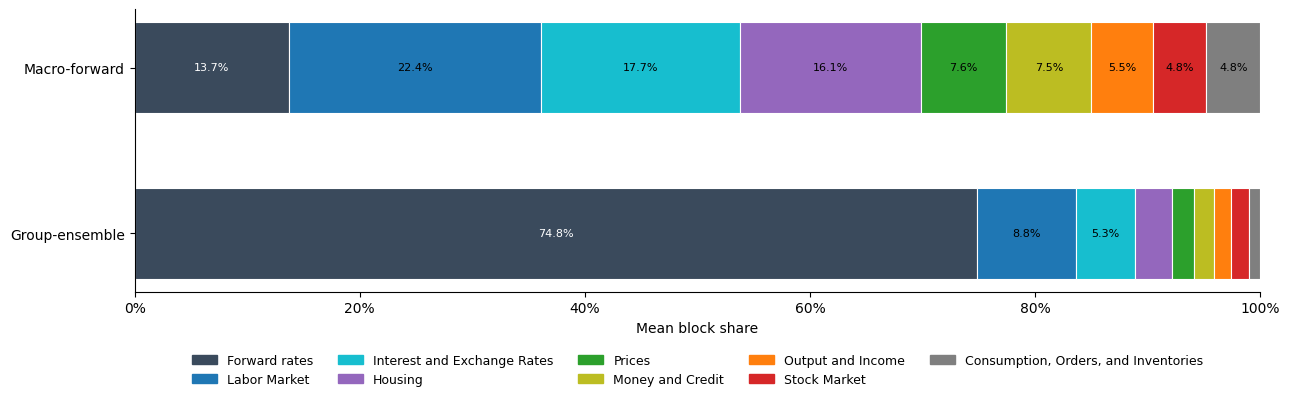


=== Block shares (%) — mean_t Σ_f |SHAP| · 10Y ===
model                                 group_ensemble  macro_forward
block                                                              
forward                                        74.85          13.71
Labor Market                                    8.80          22.37
Interest and Exchange Rates                     5.27          17.74
Housing                                         3.21          16.05
Prices                                          1.98           7.58
Money and Credit                                1.74           7.54
Output and Income                               1.54           5.46
Stock Market                                    1.58           4.76
Consumption, Orders, and Inventories            1.03           4.79


In [ ]:
t1 = (
    block_mass
    .groupby(['model', 'block'])['mass'].mean()
    .unstack('block').reindex(columns=BLOCK_ORDER).fillna(0.0)
)
shares = t1.div(t1.sum(axis=1), axis=0)

_models_bar = list(MODELS_PLOT_ORDER)

fig, ax_bar = plt.subplots(figsize=(13, 4.25))
for i, mdl in enumerate(_models_bar):
    left = 0.0
    row = shares.loc[mdl]
    for b in BLOCK_ORDER:
        w = float(row[b])
        if w <= 0:
            continue
        ax_bar.barh(i, w, left=left, color=BLOCK_COLOURS[b],
                    edgecolor='white', linewidth=0.8, height=0.55)
        if w >= 0.04:
            ax_bar.text(left + w / 2, i, f'{w*100:.1f}%', ha='center', va='center',
                        fontsize=8, color='white' if b == 'forward' else 'black')
        left += w

ax_bar.set_yticks(range(len(_models_bar)))
ax_bar.set_yticklabels([MODEL_DISPLAY_NAMES.get(m, m.replace('_', ' ')) for m in _models_bar])
ax_bar.invert_yaxis()  # first in MODELS_PLOT_ORDER at top (Macro-forward, then Group ensemble)
ax_bar.set_xlim(0, 1)
ax_bar.set_xticks(np.linspace(0, 1, 6))
ax_bar.set_xticklabels([f'{int(v*100)}%' for v in np.linspace(0, 1, 6)])
ax_bar.set_xlabel(f'Mean block share')
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=BLOCK_COLOURS[b]) for b in BLOCK_ORDER]
fig.tight_layout()
fig.subplots_adjust(bottom=0.30)
ax_bar.legend(
    handles, [block_label(b) for b in BLOCK_ORDER],
    loc='upper center', bbox_to_anchor=(0.5, -0.18),
    ncol=min(len(BLOCK_ORDER), 5), frameon=False, fontsize=9,
)
plt.show()

print()
mat_label = f'{int(MATURITY_FOR_COMPARE)//12}Y'
print(f'=== Block shares (%) — mean_t Σ_f |SHAP| · {mat_label} ===')
print(((shares * 100).round(2).T).to_string())


## Macro ranking

**Code.** Same as the **right-hand** donut from the earlier figure: **drop forwards** from the composition `shares`, **renormalize** wedges to 100% across **FRED-MD macro groups** only (gross \(\|\overline{\text{SHAP}}\|\) within macro). **No** per-series bar chart — only the circle(s).

**Plot.** One donut per model — **Macro-forward** **left**, **Group ensemble** **right** (`MODELS_PLOT_ORDER`).


/tmp/ipykernel_1230490/3002539410.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.6)


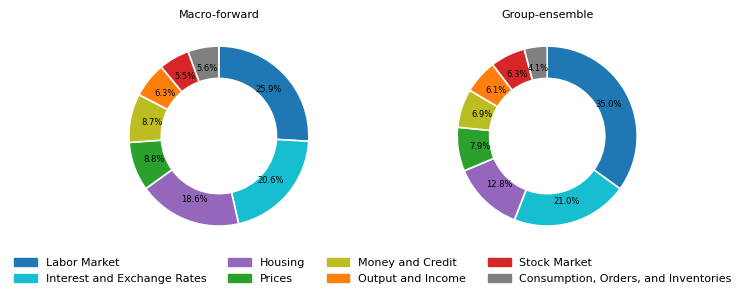

In [ ]:
tier2_label_pct_min = 3.0

_models = list(MODELS_PLOT_ORDER)
ncol = len(_models)
# Reduce figure size and extra padding for a tighter plot
fig, axes = plt.subplots(
    1, ncol,
    figsize=(3.3 * ncol, 3.0),
    squeeze=False,
    gridspec_kw=dict(wspace=0.15, left=0.05, right=0.98, top=0.88, bottom=0.13),
)
axes = axes.ravel()

for ax, mdl in zip(axes, _models):
    row = shares.loc[mdl].drop('forward', errors='ignore')
    row = row / row.sum()
    colours_pie = [BLOCK_COLOURS[b] for b in row.index]
    _, _, autotexts = ax.pie(
        row.values,
        colors=colours_pie,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.36, edgecolor='white', linewidth=1.2),
        autopct=lambda p: f'{p:.1f}%' if p >= tier2_label_pct_min else '',
        pctdistance=0.76,
    )
    for t in autotexts:
        t.set_fontsize(6)
    ax.set_aspect('equal')
    disp = MODEL_DISPLAY_NAMES.get(mdl, mdl.replace('_', ' '))
    ax.set_title(
        f'{disp}',
        fontsize=8, pad=4,
    )

handles = [plt.Rectangle((0, 0), 1, 1, color=BLOCK_COLOURS[b]) for b in _macro_order]
fig.legend(
    handles,
    [block_label(b) for b in _macro_order],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=min(len(_macro_order), 4),
    frameon=False,
    fontsize=8,
)
plt.tight_layout(pad=0.6)
plt.subplots_adjust(left=0.07, right=0.97, bottom=0.19, top=0.80, wspace=0.13)
plt.show()


## Spanning (macro vs forwards)

**Code.** Computes a **daily series** \(\mathcal{A}_{\mathrm{macro}}/(\mathcal{A}_{\mathrm{macro}}+\mathcal{A}_{\mathrm{fwd}})\) from summed block masses (same **gross** DeepSHAP mass as elsewhere). Plot shows **monthly** values, optionally a moving average (default \(6\) months), dashed **sample mean**, grey **NBER recession** bands, repeated **per model** in **`MODELS_COMPARE`** at **`MATURITY_FOR_COMPARE`**.

**Plot.** Tracks whether “macro attribution” dominates **versus** forwards over calendar time \(t\) — the usual **single‑hypothesis spanning read** expressed in attribution space.


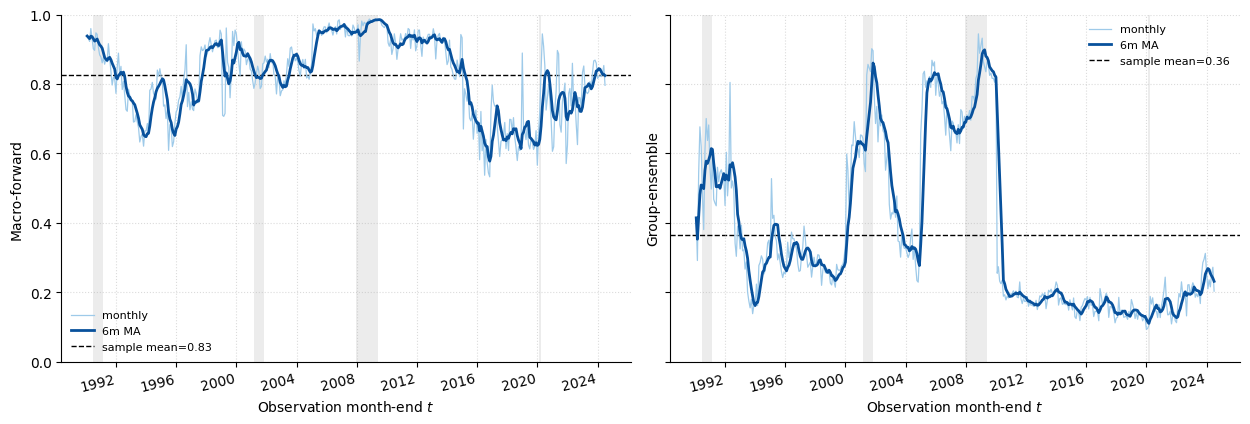


=== DeepSHAP macro share · 10Y ===
macro_forward count    414.000
mean       0.825
std        0.113
min        0.532
25%        0.747
50%        0.845
75%        0.926
max        0.987
group_ensemble count    414.000
mean       0.365
std        0.235
min        0.092
25%        0.181
50%        0.272
75%        0.550
max        0.944


In [ ]:
# ── Spanning: DeepSHAP gross — one curve per model (fixed maturity in loader) ──
span_ma_months = 6  # moving-average window (months); reference figures use 6m MA

nber_recessions = [
    ('1990-07-01', '1991-03-01'), ('2001-03-01', '2001-11-01'),
    ('2007-12-01', '2009-06-01'), ('2020-02-01', '2020-04-01'),
]
nber_recessions = [(pd.Timestamp(a), pd.Timestamp(b)) for a, b in nber_recessions]

def shade_recessions(ax, alpha=0.15, color='0.5'):
    # No change needed here.
    y0, y1 = ax.get_ylim()
    for start, end in nber_recessions:
        ax.axvspan(start, end, facecolor=color, alpha=alpha, linewidth=0, zorder=0)
    ax.set_ylim(y0, y1)

def _macro_share_deep_from_block_mass(bm: pd.DataFrame, model_key: str) -> pd.Series:
    sub = bm[bm['model'] == model_key].copy()
    sub['kind'] = np.where(sub['block'] == 'forward', 'forward', 'macro')
    tot = sub.groupby(['date', 'kind'])['mass'].sum().unstack('kind').fillna(0.0)
    return (tot['macro'] / (tot['forward'] + tot['macro']).replace(0, np.nan)).sort_index()

def _plot_spanning_models(fig, axes, series_by_model: dict, model_keys: list, note_positions=None, legend_loc='auto'):
    """
    note_positions: dict mapping model_key to {"x": float, "y": float, "ha": str, "va": str} or None.
    If specified, will pass these to ax.text for 'no data' note positioning.
    legend_loc: if "auto", chooses legend location based on content.
    """
    ax_list = np.asarray(axes, dtype=object).ravel().tolist()
    if len(ax_list) != len(model_keys):
        raise ValueError(f'Expected {len(model_keys)} axes, got {len(ax_list)}')
    mat_lbl = f'{int(MATURITY_FOR_COMPARE)//12}Y'
    for i, (ax, mdl) in enumerate(zip(ax_list, model_keys)):
        lbl = MODEL_DISPLAY_NAMES.get(mdl, mdl.replace('_', ' '))
        monthly = series_by_model.get(mdl, pd.Series(dtype=float))
        monthly = monthly.dropna().sort_index()
        if monthly.empty:
            # Allow override of note position via a dict; otherwise default as before.
            if note_positions and mdl in note_positions:
                note_pos = note_positions[mdl]
                ax.text(
                    note_pos.get("x", 0.5),
                    note_pos.get("y", 0.5),
                    'no data',
                    ha=note_pos.get("ha", "center"),
                    va=note_pos.get("va", "center"),
                    transform=ax.transAxes
                )
            else:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
            ax.set_ylabel(f'{lbl}')
            ax.set_xlabel(r'Observation month-end $t$', fontsize=10)
            continue
        ma = monthly.rolling(span_ma_months, min_periods=1).mean()
        mean_v = float(monthly.mean())
        ax.plot(monthly.index, monthly, color='#9ecae9', linewidth=0.9, label='monthly', zorder=2)
        ax.plot(ma.index, ma, color='#08519c', linewidth=2.0, label=f'{span_ma_months}m MA', zorder=3)
        ax.axhline(mean_v, color='black', linestyle='--', linewidth=1.0,
                   label=f'sample mean={mean_v:.2f}', zorder=1)
        shade_recessions(ax)
        ax.set_ylim(0, 1)
        ax.set_ylabel(
            f'{lbl}',
            fontsize=10,
        )
        # SIMPLIFIED LEGEND POSITION: legend always inside, at "best"
        ax.legend(frameon=False, loc='best', fontsize=8)
        ax.grid(True, linestyle=':', alpha=0.45)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_xlabel(r'Observation month-end $t$')
    fig.autofmt_xdate(rotation=14, ha='right')
    fig.tight_layout()

# You can specify note positions for models where 'no data' gets covered.
# Example: {"model_key": {"x":0.6, "y":0.2, "ha":"left", "va":"center"} }
# Start with empty (or provide overrides below).
no_data_note_positions = {}

deep_ts_by_model = {m: _macro_share_deep_from_block_mass(block_mass, m) for m in MODELS_PLOT_ORDER}

fig1, axes1 = plt.subplots(
    1, len(MODELS_PLOT_ORDER), figsize=(6.3 * len(MODELS_PLOT_ORDER), 4.35), sharey=True, squeeze=False,
)

# All legends now inside their plots.
_plot_spanning_models(
    fig1,
    axes1,
    deep_ts_by_model,
    list(MODELS_PLOT_ORDER),
    note_positions=no_data_note_positions,
    legend_loc='auto'
)

plt.show()

print()
mat_lbl = f'{int(MATURITY_FOR_COMPARE)//12}Y'
print(f'=== DeepSHAP macro share · {mat_lbl} ===')
for mdl, s in deep_ts_by_model.items():
    print(mdl, s.describe().round(3).to_string())


### Resesjoner: hvor «makrodrevet» er attribusjonen?

Figuren over viser makro-andelen \(\mathcal{A}_{\mathrm{macro}}/(\mathcal{A}_{\mathrm{macro}}+\mathcal{A}_{\mathrm{fwd}})\) med grå **NBER-resesjonsbånd** (samme intervaller som i `shade_recessions`). Cellen under klassifiserer hver **observasjonsmåned** \(t\) som resesjon hvis kalendermåneden overlapper NBER-vinduet (måned \(\cap\) intervall).

**Tolking.** Dette er *attribusjon i forklaringsrom* (DeepSHAP-masse aggregert til forwards vs. makroblokker), ikke en direkte test av prediksjonsbidrag eller økonomisk spanning. Høyere makro-andel i en resesjon betyr at modellen — gjennomsnitt over seeds — den måneden tilskriver **relativt mer** absolutt SHAP til FRED-temaene enn til forwardkurven.

Vi rapporterer gjennomsnitt/mediansammenligning over alle måneder med SHAP-data, **Mann–Whitney** \(p\) (to-halet) mellom resesjons- og ikke-resesjonsmåneder, og gjennomsnitt **per resesjonsepisode**. Korte episoder (særlig 2020) gir få punkter; bruk \(p\)-verdiene som grove indikasjoner, ikke sterke konklusjoner.


=== NBER vs øvrige måneder · 10Y · DeepSHAP macro share ===


,model,mean_rec,mean_exp,median_rec,median_exp,Δ mean (rec − exp),n_rec_m,n_exp_m,Mann–Whitney p
0,Macro-forward,0.9123,0.8157,0.9416,0.8304,0.0966,40,374,0.0
1,Group-ensemble,0.7004,0.3286,0.7571,0.2555,0.3718,40,374,0.0



=== Per resesjonsepisode · 10Y · DeepSHAP macro share ===


model,Group-ensemble,Macro-forward
episode,,
COVID-19,0.1525,0.8351
Dot-com / 2001,0.7824,0.8330
Early 1990s,0.5693,0.8939
GFC,0.8102,0.9707


model,Group-ensemble,Macro-forward
episode,,
COVID-19,3,3
Dot-com / 2001,9,9
Early 1990s,9,9
GFC,19,19


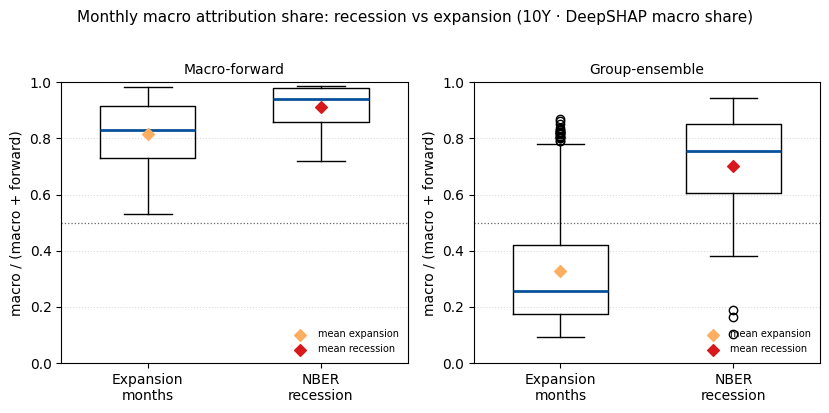

In [ ]:
# ── Deeper read: macro attribution share inside vs outside NBER recessions ──
from scipy import stats

try:
    from IPython.display import display
except ImportError:
    display = print


def recession_mask_for_index(idx: pd.DatetimeIndex, nber_list: list) -> pd.Series:
    """True where observation month (period 'M') lies inside any NBER [start,end] inclusive."""
    periods = idx.to_period("M")
    m = np.zeros(len(idx), dtype=bool)
    for start, end in nber_list:
        ps, pe = start.to_period("M"), end.to_period("M")
        m |= (periods >= ps) & (periods <= pe)
    return pd.Series(m, index=idx, name="nber_recession")


agg_rows = []
episode_rows = []
episode_labels = [
    "Early 1990s",
    "Dot-com / 2001",
    "GFC",
    "COVID-19",
]

for mdl in MODELS_PLOT_ORDER:
    s = deep_ts_by_model.get(mdl, pd.Series(dtype=float)).dropna().sort_index()
    if s.empty:
        continue

    rm = recession_mask_for_index(s.index, nber_recessions)
    rec_vals = s[rm]
    exp_vals = s[~rm]

    mw_p = np.nan
    if len(rec_vals) >= 3 and len(exp_vals) >= 3:
        _, mw_p = stats.mannwhitneyu(
            rec_vals.values,
            exp_vals.values,
            alternative="two-sided",
        )

    agg_rows.append(
        {
            "model": mdl,
            "mean_rec": rec_vals.mean(),
            "mean_exp": exp_vals.mean(),
            "median_rec": rec_vals.median(),
            "median_exp": exp_vals.median(),
            "Δ mean (rec − exp)": rec_vals.mean() - exp_vals.mean(),
            "n_rec_m": int(len(rec_vals)),
            "n_exp_m": int(len(exp_vals)),
            "Mann–Whitney p": mw_p,
        }
    )

    for lab, (start, end) in zip(episode_labels, nber_recessions):
        rm_ep = recession_mask_for_index(s.index, [(start, end)])
        seg = s[rm_ep]
        episode_rows.append(
            {
                "episode": lab,
                "model": mdl,
                "mean_macro_share": seg.mean(),
                "n_months": int(len(seg)),
            }
        )

agg_df = pd.DataFrame(agg_rows)
ep_df = pd.DataFrame(episode_rows)

mat_title = f"{int(MATURITY_FOR_COMPARE) // 12}Y · DeepSHAP macro share"

print(f"\n=== NBER vs øvrige måneder · {mat_title} ===")
if agg_df.empty:
    print("(ingen serie — kjør spanning-cellen over først)")
else:
    disp = agg_df.copy()
    disp["model"] = disp["model"].map(lambda x: MODEL_DISPLAY_NAMES.get(x, x))
    for c in ["mean_rec", "mean_exp", "median_rec", "median_exp", "Δ mean (rec − exp)", "Mann–Whitney p"]:
        disp[c] = disp[c].round(4)
    display(disp)

print(f"\n=== Per resesjonsepisode · {mat_title} ===")
if not ep_df.empty:
    ep_pivot = ep_df.pivot(index="episode", columns="model", values="mean_macro_share")
    ep_pivot = ep_pivot.rename(columns={k: MODEL_DISPLAY_NAMES.get(k, k) for k in ep_pivot.columns})
    ep_counts = ep_df.pivot(index="episode", columns="model", values="n_months")
    ep_counts = ep_counts.rename(columns={k: MODEL_DISPLAY_NAMES.get(k, k) for k in ep_counts.columns})
    display(ep_pivot.round(4))
    display(ep_counts.astype(int))

# Boxplots: same macro-share monthly observations, split recession vs expansion
fig_r, axes_r = plt.subplots(
    1,
    len(MODELS_PLOT_ORDER),
    figsize=(4.2 * len(MODELS_PLOT_ORDER), 4.0),
    squeeze=False,
)
for ax, mdl in zip(axes_r[0], MODELS_PLOT_ORDER):
    s = deep_ts_by_model.get(mdl, pd.Series(dtype=float)).dropna()
    lbl = MODEL_DISPLAY_NAMES.get(mdl, mdl.replace("_", " "))
    if s.empty:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(lbl, fontsize=10)
        continue
    rm = recession_mask_for_index(s.index, nber_recessions)
    data = [s[~rm].values, s[rm].values]
    bp = ax.boxplot(
        data,
        widths=0.55,
        medianprops=dict(color="#08519c", linewidth=2),
    )
    ax.set_xticklabels(["Expansion\nmonths", "NBER\nrecession"])
    ax.axhline(0.5, color="0.4", linestyle=":", linewidth=0.9, zorder=0)
    shade_mean_exp = float(s[~rm].mean()) if (~rm).any() else np.nan
    shade_mean_rec = float(s[rm].mean()) if rm.any() else np.nan
    ax.scatter([1], [shade_mean_exp], marker="D", color="#fdae61", s=36, zorder=5, label="mean expansion")
    ax.scatter([2], [shade_mean_rec], marker="D", color="#d7191c", s=36, zorder=5, label="mean recession")
    ax.set_ylim(0, 1)
    ax.set_ylabel(r"macro / (macro + forward)")
    ax.set_title(lbl, fontsize=10)
    ax.grid(True, axis="y", linestyle=":", alpha=0.45)
    ax.legend(loc="lower right", fontsize=7, frameon=False)

fig_r.suptitle(
    f"Monthly macro attribution share: recession vs expansion ({mat_title})",
    fontsize=11,
    y=1.02,
)
fig_r.tight_layout()
plt.show()

## Block shares over time

**Code.** Each date sums block masses to \(\mathcal{A}_{g,\mathrm{mdl}}(t)\) at **`MATURITY_FOR_COMPARE`** and divides by \(\sum_{g'}\mathcal{A}_{g',\mathrm{mdl}}(t)\) so block **shares sum to \(1\)** cross‑sectionally (\(100\\%\) stacks). Applies a configurable **rolling mean** smooth (default configurable months) so the stack is readable.

**Plot.** **Area chart** stacked to 100\\% \(y\) as a function of month‑end \(t\) — temporal evolution of *which themes matter when*, **one panel per model**.


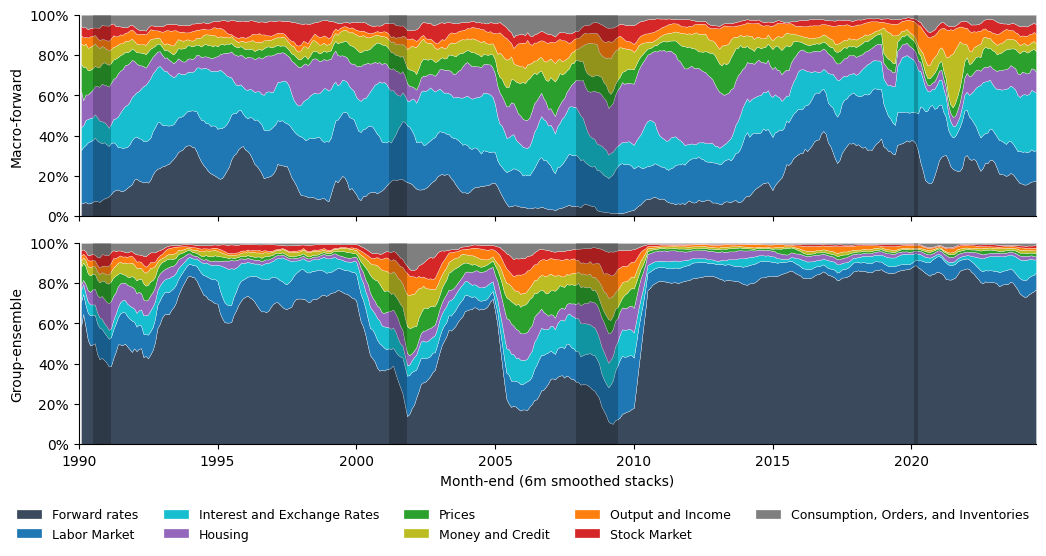

In [ ]:
tier4_smoothing = 6


def _block_shares_ts(model_key: str) -> pd.DataFrame:
    sub = block_mass[block_mass['model'] == model_key]
    wide = (
        sub.pivot_table(index='date', columns='block', values='mass', aggfunc='sum')
        .reindex(columns=BLOCK_ORDER).fillna(0.0)
    )
    wide = wide.div(wide.sum(axis=1).replace(0, np.nan), axis=0)
    if tier4_smoothing > 1:
        wide = wide.rolling(tier4_smoothing, min_periods=1).mean()
    return wide.sort_index()


import matplotlib.dates as mdates

# NBER recession windows (peak→trough). Fallback if the spanning cell above wasn't run.
if 'nber_recessions' not in globals():
    nber_recessions = [(pd.Timestamp(a), pd.Timestamp(b)) for a, b in [
        ('1990-07-01', '1991-03-01'), ('2001-03-01', '2001-11-01'),
        ('2007-12-01', '2009-06-01'), ('2020-02-01', '2020-04-01'),
    ]]

# Precompute per-model frames so the x-range can be fixed exactly to the data (no padding).
_dfs = {mdl: _block_shares_ts(mdl) for mdl in MODELS_PLOT_ORDER}
x_min = pd.Timestamp('1990-01-01')
x_max = max(df.index.max() for df in _dfs.values())

fig, axes = plt.subplots(
    len(MODELS_PLOT_ORDER), 1, figsize=(12, 3.0 * len(MODELS_PLOT_ORDER)), sharex=True,
)
if len(MODELS_PLOT_ORDER) == 1:
    axes = [axes]

for ax, mdl in zip(axes, MODELS_PLOT_ORDER):
    df = _dfs[mdl]
    ax.stackplot(
        df.index, df[BLOCK_ORDER].T.values,
        colors=[BLOCK_COLOURS[b] for b in BLOCK_ORDER],
        labels=[block_label(b) for b in BLOCK_ORDER],
        edgecolor='white', linewidth=0.2,
    )
    # NBER recessions: darken the whole stack inside each recession window by overlaying
    # a translucent dark band on top (so every block colour reads a few shades darker).
    for r_start, r_end in nber_recessions:
        if r_end < x_min or r_start > x_max:
            continue
        ax.axvspan(max(r_start, x_min), min(r_end, x_max),
                   facecolor='black', alpha=0.22, linewidth=0, zorder=3)
    ax.set_ylim(0, 1)
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.set_yticklabels([f'{int(v*100)}%' for v in np.linspace(0, 1, 6)])
    lbl = MODEL_DISPLAY_NAMES.get(mdl, mdl.replace('_', ' '))
    ax.set_ylabel(
        f'{lbl}'
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Trim the axis exactly to the data: 1990 → last observation, no side white space.
    ax.set_xlim(x_min, x_max)
    ax.margins(x=0)
    # Ticks every five years from 1990.
    ax.xaxis.set_major_locator(mdates.YearLocator(base=5, month=1, day=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

handles, labels = axes[0].get_legend_handles_labels()
plt.tight_layout(rect=[0.06, 0.06, 0.94, 0.93])

fig.legend(
    handles, labels,
    ncol=min(len(BLOCK_ORDER), 5),
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
    frameon=False,
    fontsize=9,
)

axes[-1].set_xlabel(f'Month-end ({tier4_smoothing}m smoothed stacks)')

fig.subplots_adjust(bottom=0.18)
plt.show()


## Block shares over time — 30-month tuning run

Same stacked block-share figure as above, but for the hyperparameter-tuning sensitivity run: the group-ensemble re-trained with a **30-month** retuning schedule (KR, annual non-overlapping, realtime macro). Loaded independently from `artifacts/shap/30_month_tuning_run_1971_2025_kr_ANNUAL_NONOVERLAPPING_realtime/…`.

The only methodological change versus the baseline figure is the **x-axis tick alignment**: ticks are placed on the **30-month retuning boundaries** (starting at the 1990 OOS start) rather than every five years, so the grid lines up with this run's tuning schedule. Colours, block ordering, smoothing, and the NBER recession shading are kept identical to the baseline for a like-for-like read.

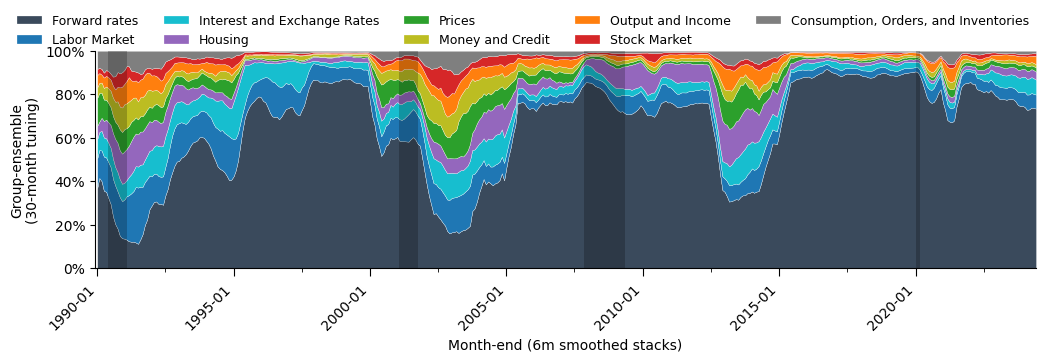

In [ ]:
import matplotlib.dates as mdates

# 30-month tuning run (KR annual non-overlapping, realtime, group ensemble).
TUNING30_SHAP_RUN = (
    '30_month_tuning_run_1971_2025_kr_ANNUAL_NONOVERLAPPING_realtime/'
    'group_ens_ann_fwd3&3_grp1_100runs_top10/20260604_003621'
)
TUNING_EVERY_MONTHS = 30                       # this run's retuning cadence
OOS_START_TUNE = pd.Timestamp('1990-01-31')    # first tuning boundary

# NBER recession windows — fallback if the spanning/baseline cell wasn't run.
if 'nber_recessions' not in globals():
    nber_recessions = [(pd.Timestamp(a), pd.Timestamp(b)) for a, b in [
        ('1990-07-01', '1991-03-01'), ('2001-03-01', '2001-11-01'),
        ('2007-12-01', '2009-06-01'), ('2020-02-01', '2020-04-01'),
    ]]

# Load this run's SHAP and build block mass at MATURITY_FOR_COMPARE (independent of the
# baseline `block_mass`, but reusing BLOCK_ORDER / BLOCK_COLOURS for a like-for-like figure).
_ds30 = _latest_ts(REPO_ROOT / 'artifacts' / 'shap' / TUNING30_SHAP_RUN)
_sm30 = pd.read_parquet(_ds30 / 'shap_mean.parquet')
_sm30['date'] = pd.to_datetime(_sm30['date'])
_sm30['maturity'] = _sm30['maturity'].astype(str)
_sm30 = _sm30[_sm30['maturity'] == MATURITY_FOR_COMPARE].copy()
_sm30['block'] = _sm30['feature'].map(parse_block)
block_mass_30 = (
    _sm30.groupby(['date', 'block'], sort=False)['abs_mean_shap']
    .sum().reset_index(name='mass')
)

# Shares over time: same recipe + smoothing as the baseline figure.
wide30 = (
    block_mass_30.pivot_table(index='date', columns='block', values='mass', aggfunc='sum')
    .reindex(columns=BLOCK_ORDER).fillna(0.0)
)
wide30 = wide30.div(wide30.sum(axis=1).replace(0, np.nan), axis=0)
if tier4_smoothing > 1:
    wide30 = wide30.rolling(tier4_smoothing, min_periods=1).mean()
wide30 = wide30.sort_index()

x_min = pd.Timestamp('1990-01-01')
x_max = wide30.index.max()
# Tick marks on the 30-month retuning boundaries instead of every five years.
tune_ticks = pd.date_range(start=OOS_START_TUNE, end=x_max,
                           freq=pd.DateOffset(months=TUNING_EVERY_MONTHS))

fig, ax = plt.subplots(1, 1, figsize=(12, 3.4))
ax.stackplot(
    wide30.index, wide30[BLOCK_ORDER].T.values,
    colors=[BLOCK_COLOURS[b] for b in BLOCK_ORDER],
    labels=[block_label(b) for b in BLOCK_ORDER],
    edgecolor='white', linewidth=0.2,
)
# NBER recessions: darken the stack inside each window (matches the baseline figure).
for r_start, r_end in nber_recessions:
    if r_end < x_min or r_start > x_max:
        continue
    ax.axvspan(max(r_start, x_min), min(r_end, x_max),
               facecolor='black', alpha=0.22, linewidth=0, zorder=3)
ax.set_ylim(0, 1)
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_yticklabels([f'{int(v*100)}%' for v in np.linspace(0, 1, 6)])
ax.set_ylabel(f"{MODEL_DISPLAY_NAMES.get('group_ensemble', 'Group-ensemble')}\n(30-month tuning)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(x_min, x_max)
ax.margins(x=0)
# X-axis aligned with the 30-month hyperparameter-tuning schedule. Keep the full
# retuning cadence as unlabelled minor ticks, but only label every other boundary
# (every 60 months) so the axis isn't crowded.
ax.set_xticks(tune_ticks, minor=True)
ax.set_xticks(tune_ticks[::2])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', which='minor', length=3)
ax.tick_params(axis='x', which='major', length=6)
for lab in ax.get_xticklabels():
    lab.set_rotation(45)
    lab.set_ha('right')

ax.set_xlabel(
    f'Month-end ({tier4_smoothing}m smoothed stacks)'
)

handles, labels = ax.get_legend_handles_labels()
# Categories (legend) at the top, x-axis at the bottom — they no longer collide.
plt.tight_layout(rect=[0.06, 0.08, 0.94, 0.88])
fig.legend(
    handles, labels,
    ncol=min(len(BLOCK_ORDER), 5),
    loc='upper center',
    bbox_to_anchor=(0.5, 1.0),
    frameon=False,
    fontsize=9,
)
fig.subplots_adjust(top=0.86, bottom=0.22)
plt.show()

## Composition — 30-month tuning run

Overall mean block share for the 30-month tuning group ensemble (same recipe as the baseline composition figure), shown against the baseline-tuning group ensemble when available.

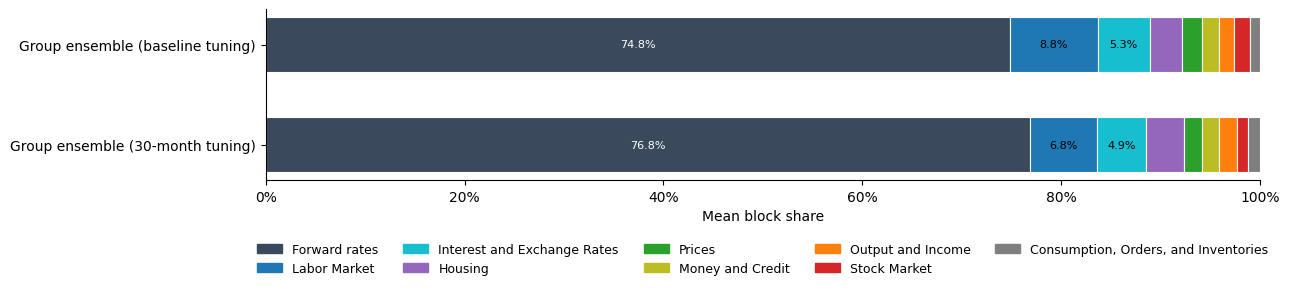


=== Block shares (%) — 30-month tuning group ensemble · 10Y ===
block
forward                                 76.82
Labor Market                             6.75
Interest and Exchange Rates              4.91
Housing                                  3.81
Prices                                   1.83
Money and Credit                         1.75
Output and Income                        1.74
Stock Market                             1.11
Consumption, Orders, and Inventories     1.27


In [ ]:
# Composition (overall mean block share) for the 30-month tuning group ensemble.
# Same recipe as the baseline composition figure: mean mass per block over dates,
# then normalise to shares. Reuses block_mass_30 from the over-time cell above.
t1_30 = (
    block_mass_30.groupby('block')['mass'].mean()
    .reindex(BLOCK_ORDER).fillna(0.0)
)
shares_30 = t1_30 / t1_30.sum()

# Stack against the baseline group ensemble when it's available so the tuning effect
# on composition is visible side by side.
rows = []
if 'shares' in globals() and 'group_ensemble' in list(getattr(shares, 'index', [])):
    rows.append(('Group ensemble (baseline tuning)', shares.loc['group_ensemble']))
rows.append(('Group ensemble (30-month tuning)', shares_30))

fig, ax_bar = plt.subplots(figsize=(13, 1.2 + 0.9 * len(rows)))
for i, (lbl, row) in enumerate(rows):
    left = 0.0
    for b in BLOCK_ORDER:
        w = float(row.get(b, 0.0))
        if w <= 0:
            continue
        ax_bar.barh(i, w, left=left, color=BLOCK_COLOURS[b],
                    edgecolor='white', linewidth=0.8, height=0.55)
        if w >= 0.04:
            ax_bar.text(left + w / 2, i, f'{w*100:.1f}%', ha='center', va='center',
                        fontsize=8, color='white' if b == 'forward' else 'black')
        left += w

ax_bar.set_yticks(range(len(rows)))
ax_bar.set_yticklabels([lbl for lbl, _ in rows])
ax_bar.invert_yaxis()
ax_bar.set_xlim(0, 1)
ax_bar.set_xticks(np.linspace(0, 1, 6))
ax_bar.set_xticklabels([f'{int(v*100)}%' for v in np.linspace(0, 1, 6)])
ax_bar.set_xlabel('Mean block share')
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=BLOCK_COLOURS[b]) for b in BLOCK_ORDER]
fig.tight_layout()
fig.subplots_adjust(bottom=0.38)
ax_bar.legend(
    handles, [block_label(b) for b in BLOCK_ORDER],
    loc='upper center', bbox_to_anchor=(0.5, -0.30),
    ncol=min(len(BLOCK_ORDER), 5), frameon=False, fontsize=9,
)
plt.show()

print()
mat_label = f'{int(MATURITY_FOR_COMPARE)//12}Y'
print(f'=== Block shares (%) — 30-month tuning group ensemble · {mat_label} ===')
print((shares_30 * 100).round(2).to_string())

## Seed dispersion (time-pooled by seed identity)

**Data.** `per_seed_shap.parquet` already contains **only the top‑k seeds selected at each forecast date** (10 per date for `…_top10` runs) — not all 100 training seeds. But the seed *identities* rotate over time (many distinct seeds appear across the sample).

**Code.** Aggregates **within each seed \(s\)** the time mean of \(| \mathrm{SHAP} |\) per block, then block shares \(\bar{\mathcal{A}}^{(s)}_{G}/\sum_{G'}\bar{\mathcal{A}}^{(s)}_{G'}\). Each dot is one seed that ever entered top‑k on at least one date; the time average is taken **only over dates where that seed was selected** (unequal coverage). **`|\`** marker = ensemble mean from **`shap_mean`**.

**Plot.** Dispersion of thematic shares across **seed identities** (time-pooled). One column **per model** at **`MATURITY_FOR_COMPARE`**. See the next section for **within-date** top‑k dispersion (the ensemble-relevant notion of stability).


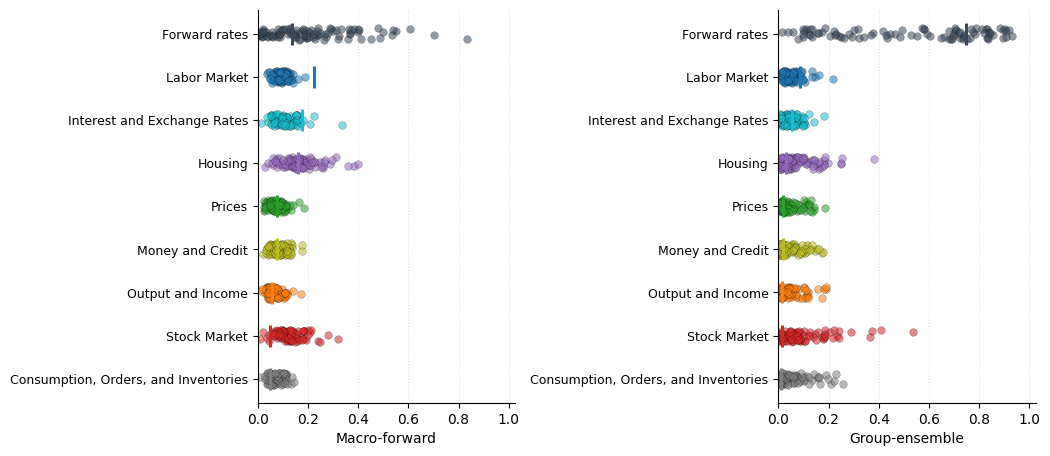


=== Across-seed SD of share (%) · 10Y ===
                Forward rates  Labor Market  Interest and Exchange Rates  Housing  Prices  Money and Credit  Output and Income  Stock Market  Consumption, Orders, and Inventories
model                                                                                                                                                                             
group_ensemble          28.47          3.52                         3.32     6.84    4.10              4.46               4.58          9.74                                  5.92
macro_forward           16.42          2.54                         4.30     6.76    2.97              3.07               2.60          5.13                                  2.56


In [ ]:
if pss is None:
    print('Skipping seed stability: per_seed_shap.parquet not found for every model. Re-run SHAP with save_per_seed=True.')
else:
    pss2 = pss.copy()
    pss2['block'] = pss2['feature'].map(parse_block)
    pss2['abs_shap'] = pss2['shap_value'].abs()

    seed_mass = (
        pss2.groupby(['model', 'seed', 'block'])['abs_shap']
        .mean().reset_index(name='mass')
    )
    seed_mass['denom'] = seed_mass.groupby(['model', 'seed'])['mass'].transform('sum')
    seed_mass['share'] = seed_mass['mass'] / seed_mass['denom']

    ens = (
        block_mass
        .groupby(['model', 'block'])['mass'].mean().reset_index()
    )
    ens['denom'] = ens.groupby('model')['mass'].transform('sum')
    ens['share'] = ens['mass'] / ens['denom']

    fig, axes = plt.subplots(
        1, len(MODELS_PLOT_ORDER),
        figsize=(6.0 * len(MODELS_PLOT_ORDER), 0.45 * len(BLOCK_ORDER) + 1.5),
        sharex=True,
    )
    if len(MODELS_PLOT_ORDER) == 1:
        axes = [axes]

    rng = np.random.default_rng(0)
    for ax, mdl in zip(axes, MODELS_PLOT_ORDER):
        for yi, g in enumerate(BLOCK_ORDER[::-1]):
            sdf = seed_mass[(seed_mass['model'] == mdl) & (seed_mass['block'] == g)]
            if not sdf.empty:
                jitter = rng.uniform(-0.14, 0.14, size=len(sdf))
                ax.scatter(
                    sdf['share'].values, yi + jitter,
                    color=BLOCK_COLOURS[g], alpha=0.55, s=30,
                    edgecolor='black', linewidth=0.25,
                )
            erow = ens[(ens['model'] == mdl) & (ens['block'] == g)]
            if not erow.empty:
                ax.scatter(erow['share'].values, [yi], color=BLOCK_COLOURS[g],
                           marker='|', s=260, linewidth=2.2)
        ax.set_yticks(range(len(BLOCK_ORDER)))
        ax.set_yticklabels([block_label(b) for b in BLOCK_ORDER[::-1]], fontsize=9)
        ax.set_xlim(0, max(0.7, float(seed_mass['share'].max()) * 1.1))
        lbl = MODEL_DISPLAY_NAMES.get(mdl, mdl.replace('_', ' '))
        ax.set_xlabel(
            f'{lbl}',
            fontsize='10',
        )
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='x', linestyle=':', alpha=0.4)

    fig.tight_layout(rect=[0.06, 0.10, 0.94, 0.94])
    plt.show()

    sd_tbl = (
        seed_mass.groupby(['model', 'block'])['share']
        .std(ddof=0).mul(100).round(2).unstack('block')[BLOCK_ORDER]
    )
    sd_tbl.columns = [block_label(c) for c in sd_tbl.columns]
    print()
    mat_lbl = f'{int(MATURITY_FOR_COMPARE)//12}Y'
    print(f'=== Across-seed SD of share (%) · {mat_lbl} ===')
    print(sd_tbl.to_string())


## Within-date top-k seed stability

**Question.** Do the **10 seeds in the ensemble on date \(t\)** agree on block-level attribution at that date?

**Method.** From `per_seed_shap` (already restricted to top-k seeds each date): for each \((\text{model}, t, s)\) compute block shares, then **within each \((\text{model}, t, G)\)** take the std (or max−min) of shares across the \(k\) seeds selected that day. Boxplots summarize the distribution of those **within-date** spreads over forecast dates.

**Contrast with above.** The previous plot pools by **seed identity** over time (each seed averaged over the dates it happened to be in top-k). This plot never tracks seed IDs across dates — it measures disagreement **inside the ensemble at each forecast date**, which is usually **noisier / more unstable** and matches how the ensemble SHAP mean is formed.



Top-k seeds per forecast date (should be 10 for top10 runs):
                count  mean  std   min   25%   50%   75%   max
model                                                         
group_ensemble  414.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0
macro_forward   414.0  10.0  0.0  10.0  10.0  10.0  10.0  10.0



/tmp/ipykernel_1230490/2114880997.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_1230490/2114880997.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


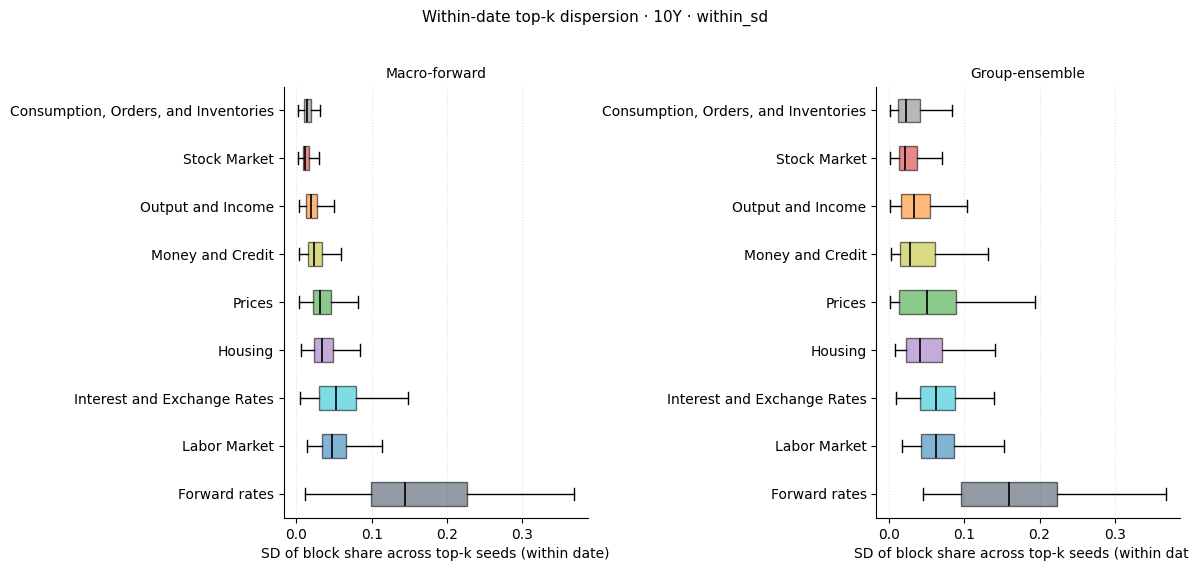

TypeError: Must provide 'func' or tuples of '(column, aggfunc).

In [ ]:
if pss is None:
    print('Skipping within-date top-k stability: per_seed_shap.parquet missing.')
else:
    pss_wd = pss.copy()
    pss_wd['block'] = pss_wd['feature'].map(parse_block)
    pss_wd['abs_shap'] = pss_wd['shap_value'].abs()

    # Block mass per (model, date, seed) — only top-k seeds exist in pss_wd.
    seed_day_mass = (
        pss_wd.groupby(['model', 'date', 'seed', 'block'], sort=False)['abs_shap']
        .sum().reset_index(name='mass')
    )
    seed_day_mass['denom'] = (
        seed_day_mass.groupby(['model', 'date', 'seed'])['mass'].transform('sum')
    )
    seed_day_mass['share'] = seed_day_mass['mass'] / seed_day_mass['denom']

    # Sanity: should be k seeds per (model, date) at fixed maturity.
    k_by_date = (
        seed_day_mass.groupby(['model', 'date'])['seed'].nunique().rename('n_seeds')
    )
    print('Top-k seeds per forecast date (should be 10 for top10 runs):')
    print(k_by_date.groupby('model').describe().round(1).to_string())
    print()

    within_date = (
        seed_day_mass.groupby(['model', 'date', 'block'], sort=False)['share']
        .agg(within_sd='std', within_range=lambda s: s.max() - s.min())
        .reset_index()
    )
    within_date['within_sd'] = within_date['within_sd'].fillna(0.0)

    metric = 'within_sd'  # or 'within_range'
    mat_lbl = f'{int(MATURITY_FOR_COMPARE) // 12}Y'

    fig, axes = plt.subplots(
        1, len(MODELS_PLOT_ORDER),
        figsize=(6.0 * len(MODELS_PLOT_ORDER), 0.45 * len(BLOCK_ORDER) + 1.5),
        sharex=True,
    )
    if len(MODELS_PLOT_ORDER) == 1:
        axes = [axes]

    for ax, mdl in zip(axes, MODELS_PLOT_ORDER):
        sub = within_date[within_date['model'] == mdl]
        data = [
            sub.loc[sub['block'] == g, metric].values
            for g in BLOCK_ORDER
        ]
        bp = ax.boxplot(
            data,
            vert=False,
            labels=[block_label(g) for g in BLOCK_ORDER],
            patch_artist=True,
            showfliers=False,
            medianprops={'color': 'black', 'linewidth': 1.2},
        )
        for patch, g in zip(bp['boxes'], BLOCK_ORDER):
            patch.set_facecolor(BLOCK_COLOURS[g])
            patch.set_alpha(0.55)
        ax.set_xlabel(f'SD of block share across top-k seeds (within date)')
        ax.set_title(MODEL_DISPLAY_NAMES.get(mdl, mdl), fontsize=10)
        ax.grid(axis='x', linestyle=':', alpha=0.4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'Within-date top-k dispersion · {mat_lbl} · {metric}',
        fontsize=11,
        y=1.02,
    )
    fig.tight_layout()
    plt.show()

    summary = (
        within_date.groupby(['model', 'block'])[[metric]]
        .agg(median='median', p75=lambda s: s.quantile(0.75))
        .mul(100)
        .round(2)
    )
    summary.columns = ['median (pp)', 'p75 (pp)']
    summary.index = summary.index.set_levels(
        [summary.index.levels[0],
         [block_label(b) for b in summary.index.levels[1]]],
    )
    print(f'=== Within-date top-k {metric} of block share (percentage points) · {mat_lbl} ===')
    print(summary.to_string())

